# Introduction

## **Goal:**
### To analyze historical data from a UK online retail store, identify key products, trends over time and geography, as well as data anomalies, in order to provide business insights for optimizing sales, product assortment, and marketing strategies.

**Columns to use:**
`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`

# Preparation

## **Goal:**
### Prepare a ready dataset for further analysis.

## 1. Check for missing values

In [2]:
!mamba install pandas

import pandas as pd

df = pd.read_csv('dataset.csv')

missing_values = df.isnull().sum()
print(missing_values)


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.7723999999985098 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             

`Description` and `CustomerID` have missing values, so I calculate their share of the total

In [3]:
missing_customer = df['CustomerID'].isnull().sum()
total_rows = len(df)
missing_percentage = (missing_customer / total_rows) * 100
print(f"Missing CustomerID: {missing_percentage:.2f}%")

missing_desc = df['Description'].isnull().sum()
total_rows = len(df)
missing_percentage = (missing_desc / total_rows) * 100
print(f"Missing Desc: {missing_percentage:.2f}%")

Missing CustomerID: 24.93%
Missing Desc: 0.27%


So, the `Description` has a negligible number of missing values compared to `CustomerID`. 

* **Assumption:** these are anonymous or unregistered customers. 
* **Solution:** mark `CustomerID` as `99999` and `Description` as `None`. 

In [4]:
df['CustomerID'] = df['CustomerID'].fillna(99999)
df['Description'] = df['Description'].fillna('None')

df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)
# Converted decimal comma to dot and cast to float for numeric calculations.

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
# Converted to datetime format for time-based analysis.

In [5]:
# Percentage of rows with InvoiceNo starting with 'C' (cancellations)
percent_c = (df['InvoiceNo'].astype(str).str.startswith('C').sum() / df.shape[0]) * 100

# Percentage of negative Quantity values not from invoices with 'C' out of total rows
percent_neg_non_c = ((df['Quantity'] < 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))).sum() / df.shape[0] * 100

# Print results
print(f"Percentage of rows with InvoiceNo starting with 'C': {percent_c:.2f}%")
print(f"Percentage of negative Quantity not in invoices with 'C': {percent_neg_non_c:.2f}%")

Percentage of rows with InvoiceNo starting with 'C': 1.71%
Percentage of negative Quantity not in invoices with 'C': 0.25%


In [6]:
# Remove cancelled invoices, because their share is negligible
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[~((df['Quantity'] < 0) & (~df['InvoiceNo'].astype(str).str.startswith('C')))]

In [7]:
# Find rows where UnitPrice is zero
zero_prices = df[df["UnitPrice"] == 0]
zero_prices

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,None,56,2010-12-01 11:52:00,0.0,99999.0,United Kingdom
1970,536545,21134,None,1,2010-12-01 14:32:00,0.0,99999.0,United Kingdom
1971,536546,22145,None,1,2010-12-01 14:33:00,0.0,99999.0,United Kingdom
1972,536547,37509,None,1,2010-12-01 14:33:00,0.0,99999.0,United Kingdom
1987,536549,85226A,None,1,2010-12-01 14:34:00,0.0,99999.0,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,99999.0,United Kingdom
536981,581234,72817,None,27,2011-12-08 10:33:00,0.0,99999.0,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,99999.0,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,99999.0,United Kingdom


In [8]:
# Remove all rows where UnitPrice is zero because their share is negligible
df = df[df["UnitPrice"] != 0]

In [9]:
# Find rows where UnitPrice is negative
negative_prices = df[df["UnitPrice"] < 0]
negative_prices

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,99999.0,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,99999.0,United Kingdom


In [10]:
# Select rows where Description contains "Adjust bad debt" to inspect accounting adjustments

adjust_bad_debt_rows = df[df['Description'].str.contains('Adjust bad debt', case=False, na=False)]

adjust_bad_debt_rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,99999.0,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,99999.0,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,99999.0,United Kingdom


In [11]:
# Remove rows where Description contains "Adjust bad debt" as they represent noise in the dataset
df = df[~df['Description'].str.contains('Adjust bad debt', case=False, na=False)]

## Looking for min and max values

### Purpose: 
**These values can strongly affect statistics, so they need to be identified for accurate analysis.**

In [12]:
# Create TotalPrice

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


#Looking for max

max_totalprice = df.nlargest(10, 'TotalPrice')
max_totalprice

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,99999.0,United Kingdom,13541.33
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749.0,United Kingdom,4921.50


In [13]:
max_totalprice = df.nlargest(10, 'TotalPrice')
max_totalprice

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,99999.0,United Kingdom,13541.33
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749.0,United Kingdom,4921.50


### Maximum `TotalPrice` in the dataset: £168,469

In [14]:
# Remove rows with non-product descriptions that create noise in the data
noise_descriptions = ['Adjust bad debt', 'AMAZON FEE', 'POST', 'DOTCOM POSTAGE', 'Manual', 'POSTAGE']
df = df[~df['Description'].isin(noise_descriptions)]

In [34]:
# Remove the maximum to prevent it from skewing statistics and charts
df = df[df['TotalPrice'] != 168469.60]

### Looking for min values

In [16]:
min_totalprice = df.nsmallest(15, 'TotalPrice')

min_totalprice

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.001,13952.0,United Kingdom,0.001
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.001,15618.0,United Kingdom,0.001
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,0.001
361741,568375,BANK CHARGES,Bank Charges,1,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,0.001
423991,573174,16218,CARTOON PENCIL SHARPENERS,1,2011-10-28 10:25:00,0.060,99999.0,United Kingdom,0.060
500313,578757,16216,LETTER SHAPE PENCIL SHARPENER,1,2011-11-25 11:41:00,0.060,12748.0,United Kingdom,0.060
241349,558198,17038,PORCELAIN BUDAH INCENSE HOLDER,1,2011-06-27 12:49:00,0.100,14104.0,United Kingdom,0.100
257038,559509,17038,PORCELAIN BUDAH INCENSE HOLDER,1,2011-07-08 15:25:00,0.100,15920.0,United Kingdom,0.100
497822,578479,17038,PORCELAIN BUDAH INCENSE HOLDER,1,2011-11-24 12:48:00,0.100,15858.0,United Kingdom,0.100
143754,548711,47013A,WINE BOTTLE DRESSING LT.BLUE,1,2011-04-03 14:24:00,0.120,18116.0,United Kingdom,0.120


In [17]:
# Remove rows with 0.001 as they are negligible transactions creating noise
df = df[df["UnitPrice"] != 0.001]

### Minimum `TotalPrice` in the dataset: £0.06

In [18]:
# Additional columns are created from InvoiceDate to analyze purchasing patterns over time.

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday


# Basic Analysis

## Purpose: 
**Provide a basic overview of sales data by identifying top products, key markets, and trends over time.**

# 1. Top 20 Products by Revenue

In [20]:
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.9386999999992549 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                        pyhd8ed1ab_3                  conda-forge                   
+ statsmodels                   0.14.6                        np22py313h3cf259a_1           emscripten-forge              


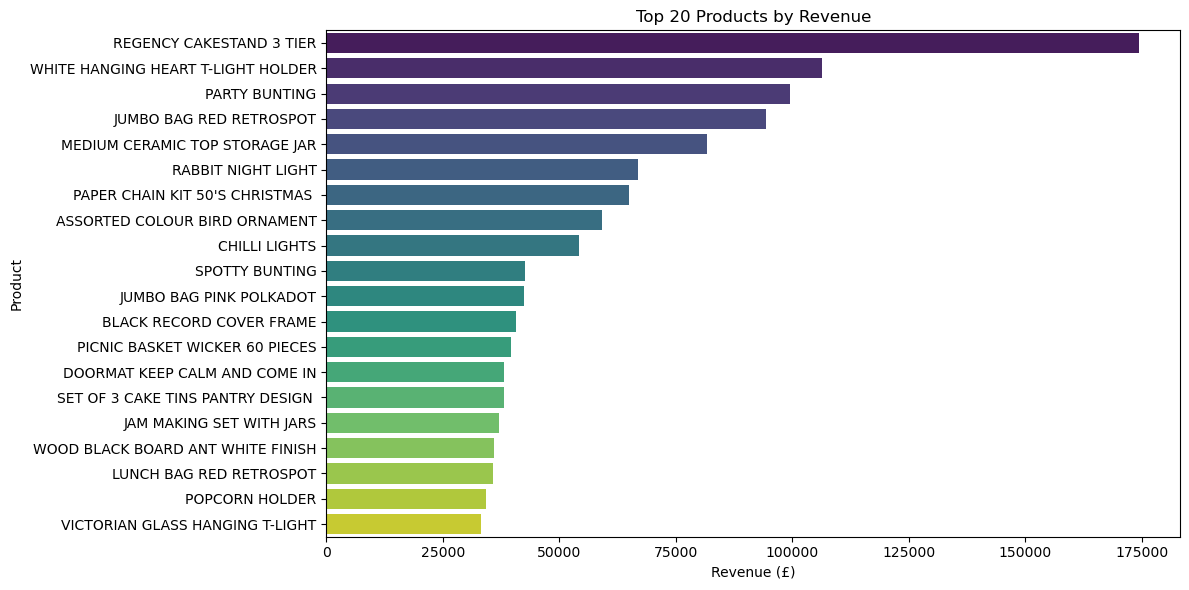

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

top_products_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(20)
top_products_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

x = top_products_revenue.values
y = top_products_revenue.index

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=x,
    y=y,
    hue=y,           
    palette="viridis",
    dodge=False,
    legend=False     
)

ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Product")
ax.set_title("Top 20 Products by Revenue")
plt.tight_layout()
plt.show()

### Insights:

Total sales are heavily concentrated in a small group of party and decor items, with the top 5 products significantly outperforming the rest of the list.

### Recommendations
**Focus budget:** direct marketing efforts toward the top 5 products to maximize return on investment.

**Maintain stock:** prevent inventory shortages for bestsellers, especially the cakestands, to avoid lost revenue.

**Create bundles:** combine top-performing items with lower-ranked products to increase the average order value.

# 2. Sales by Time

## Goal: detect seasonal peaks, optimize marketing campaigns and operations.

## - Sales by Month

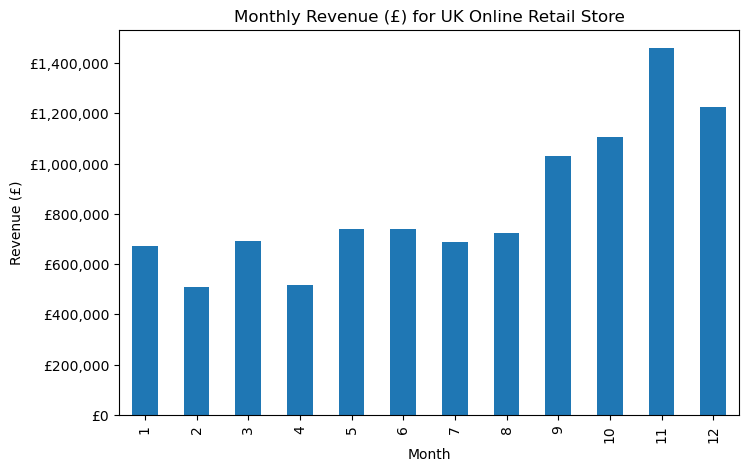

In [22]:
from matplotlib.ticker import FuncFormatter

sales_by_month = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
ax = sales_by_month.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.title("Monthly Revenue (£) for UK Online Retail Store")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.show()

### Insight: 

The data reveals a steady upward trend with a massive surge in the fourth quarter. Revenue peaks in `November`, which is nearly triple the earnings of the lowest month, `February`. This highlights a powerful seasonal sales cycle, likely driven by holiday shopping and year-end promotions.

### Recommendations:
**Capitalize on Q4:** Maximize inventory and ad spend from `September` to `November` to ride the peak trend.

**Stimulate Low Periods:** Launch aggressive promotions in `February` and `April` to stabilize cash flow.

**Retain Peak Buyers:** Offer post-holiday incentives to convert year-end shoppers into `Q1` customers.

**Scale Early:** Start ramping up operations in `August` to be fully ready for the `September` growth surge.


## - Sales by Weekday

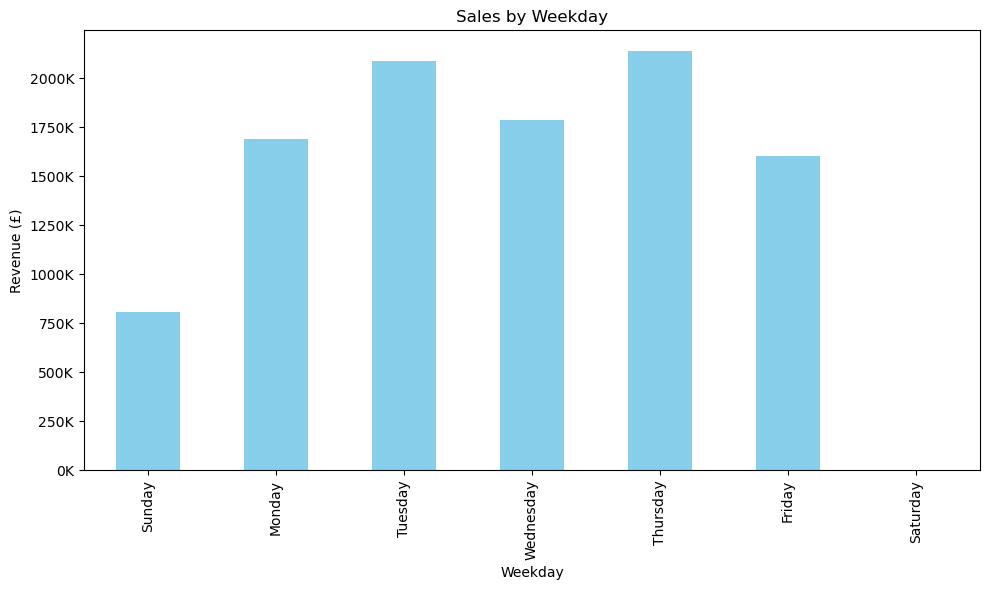

In [23]:
weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

sales_by_weekday = df.groupby('Weekday')['TotalPrice'].sum()

sales_by_weekday = sales_by_weekday.reindex(weekday_order)

plt.figure(figsize=(10,6))
ax = sales_by_weekday.plot(kind='bar', color="skyblue")

plt.xlabel("Weekday")
plt.ylabel("Revenue (£)")
plt.title("Sales by Weekday")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

## Insight:

Sales peak on `Thursday` and `Tuesday`, while Saturday shows zero sales. `Sunday` is the weakest active day.

## Recomendations:

1. **Schedule campaigns:** plan major marketing activities and newsletters for `Tuesday` and `Thursday` to capture peak buying interest.
   
3. **Boost weekends:** introduce exclusive "weekend-only" deals to drive sales on `Saturday` and `Sunday`.

5. **Scale mid-week resources:** increase staffing and logistics support on high-volume days to ensure fast order processing.
 
6. **Audit Saturday gap:** investigate why `Saturday` sales are at zero to fix potential technical issues or operational closures.

8. **Target Sunday shoppers:** offer "early-bird" discounts on `Sunday` evenings to bridge the gap before the `Monday` rush.

## - Sales by hours

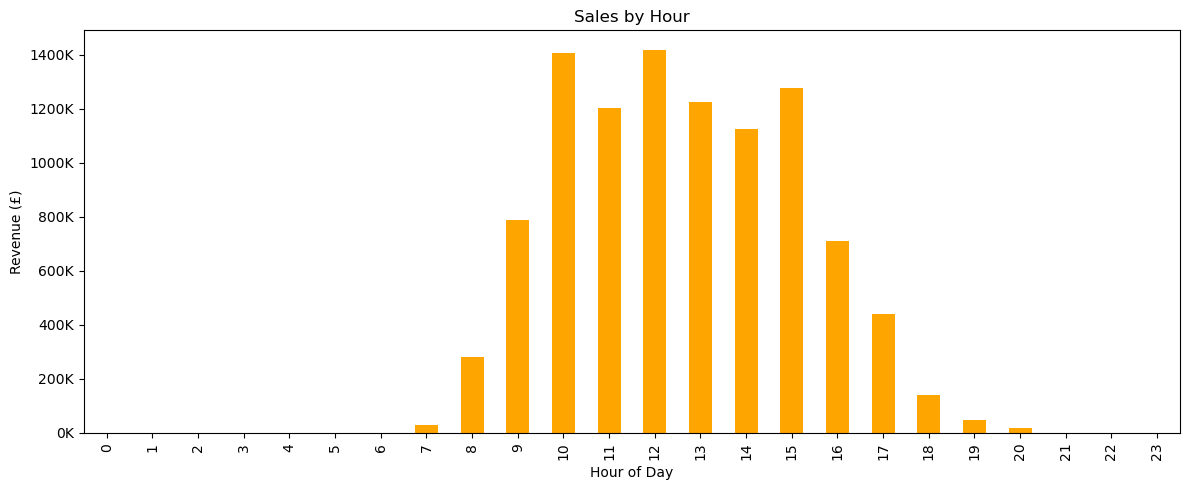

In [24]:
sales_by_hour = df.groupby('Hour')['TotalPrice'].sum()

sales_by_hour = sales_by_hour.reindex(range(24), fill_value=0)

plt.figure(figsize=(12,5))
ax = sales_by_hour.plot(kind='bar', color='orange')

plt.title("Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

## Insight:

Peak shopping activity occurs between `10:00` and `15:00`. Revenue spikes at `10` and `12`, followed by a sharp decline. Evening and nighttime hours show almost zero activity.

## Recomendations:

**Optimize ad delivery:** focus the majority of your daily advertising budget between `9:00` and `15:00` to catch customers during their most active buying window.

**Time newsletters:** send email or SMS campaigns at `9:30` to stay at the top of customers inboxes exactly when the daily peak begins.

**Align customer support:** schedule the maximum number of support staff for the `10:00–16:00` shift to handle the high volume of inquiries and orders.

# 3. Sales by country
## **Goal:** identify key markets and growth opportunities

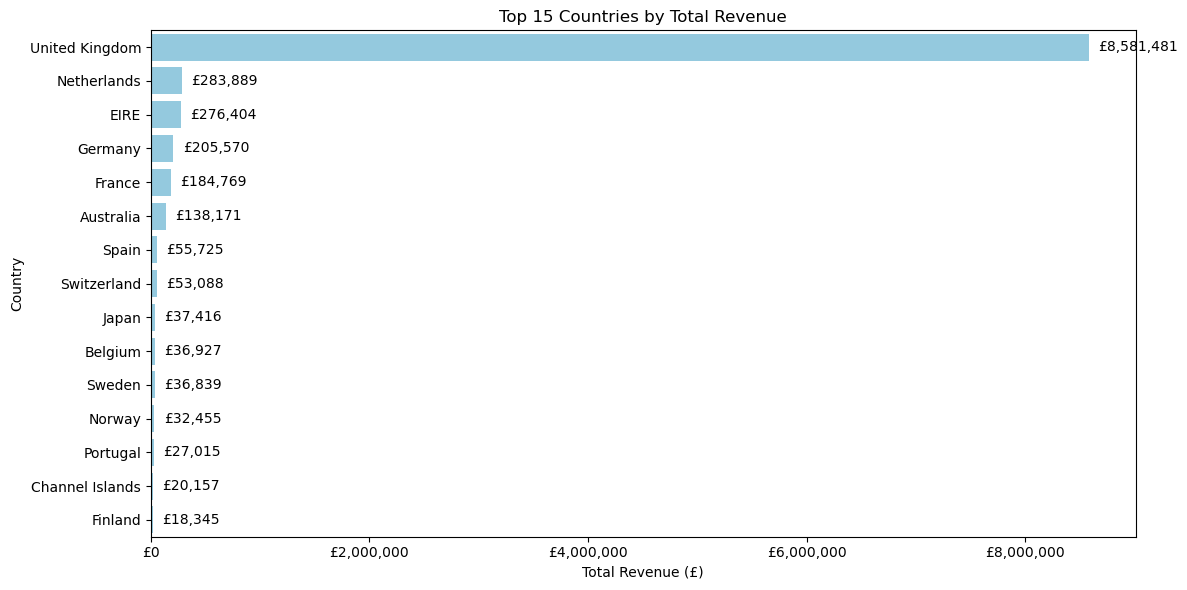

In [25]:
sales_by_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
top15_country = sales_by_country.head(15)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top15_country.values, y=top15_country.index, color="skyblue")

plt.title("Top 15 Countries by Total Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")

# Форматування X-осі як реальні цифри з комами
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'£{x:,.0f}'))

# Додаємо мітки на стовпцях
for i, v in enumerate(top15_country.values):
    ax.text(v + max(top15_country.values)*0.01, i, f'£{v:,.0f}', va='center')

plt.tight_layout()
plt.show()

## Insight:

The `United Kingdom` is the dominant market. This is dozens of times higher than the next closest markets (Netherlands and EIRE). The business is heavily dependent on a single region, while international sales remain in the early stages of growth.

## Recommendations:

**Maintain UK leadership:** prioritize resources to protect the `UK` market share, as it serves as the core financial foundation.

**Scale EU presence:** increase marketing investment in the `Netherlands`, `Germany`, and `France`, as they show the highest international potential.

**Localize marketing:** adapt product descriptions and customer support to the local languages of top European markets to boost conversion rates.

**Optimize global shipping:** review delivery costs for lower-revenue countries to make the offer more competitive.

**Analyze Australian potential:** investigate the drivers behind high sales in this distant region and consider expanding operations there.

# Customer Segmentation

## Goal:

Identify high-value, loyal, new/inactive, and lost customers, quantify their revenue contribution, and inform targeted marketing and retention strategies.

In [35]:
seg_df = df[df['CustomerID'] != 99999].copy()

rfm = seg_df.groupby('CustomerID').agg(
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

freq_threshold = rfm['Frequency'].quantile(0.8)
monetary_threshold = rfm['Monetary'].quantile(0.8)
recent_threshold = rfm['LastPurchase'].max() - pd.Timedelta(days=180)

def customer_segment(row):
    if row['Frequency'] >= freq_threshold and row['Monetary'] >= monetary_threshold:
        return 'Loyal & Frequent'
    elif row['Monetary'] >= monetary_threshold:
        return 'High Revenue (VIP)'
    elif row['LastPurchase'] >= recent_threshold:
        return 'New / Inactive'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(customer_segment, axis=1)

rfm[['CustomerID', 'Frequency', 'Monetary', 'LastPurchase', 'Segment']].head(20)

segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
print(segment_revenue)

Segment
New / Inactive        2627
Lost                   841
Loyal & Frequent       708
High Revenue (VIP)     159
Name: count, dtype: int64
Segment
High Revenue (VIP)     688383.77
Lost                   323219.64
Loyal & Frequent      5680813.11
New / Inactive        1907031.53
Name: Monetary, dtype: float64


## Insights

**1. Loyal and Frequent (708 customers):**

* Contribute most of the store’s revenue.

* Purchase often with consistent average order value.

**2. High Revenue / VIP (159 customers):**

* Purchase rarely but very high-value items.

* Their behavior heavily influences total revenue.

**3. New / Inactive (2627 customers):**

* Recently bought or haven’t purchased in a while.

* Large potential for repeat purchases if engaged.

**4. Lost (841 customers):**

* No longer purchasing.

Represents lost sales; reasons should be analyzed and addressed.

## Recommendations

**1. For Loyal and Frequent:**

* Implement loyalty programs or bonuses to encourage more frequent purchases.

* Offer personalized promotions on products they already like.

**2. For High Revenue / VIP:**

* Provide premium offers and campaigns for high-value products.

* Offer personalized service or VIP shipping.

**3. For New / Inactive:**

* Send reminders via email/SMS; offer discounts for the first repeat purchase.

* Segment further by last purchase date for precise targeting.

**4. For Lost:**

* Analyze why they stopped purchasing